Статусы заказов:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
Месячный retention:
cohort_index   0         1         2         3         4         5         6   \
cohort_month                                                                    
2016-09       1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2016-10       1.0       NaN       NaN       NaN       NaN       NaN  0.003817   
2016-12       1.0  1.000000       NaN       NaN       NaN       NaN       NaN   
2017-01       1.0  0.002789  0.002789  0.001395  0.004184  0.001395  0.004184   
2017-02       1.0  0.001843  0.003071  0.001229  0.004300  0.001229  0.002457   
2017-03       1.0  0.004395  0.003596  0.003995  0.003596  0.001598  0.001598   
2017-04       1.0  0.006206  0.002216  0.001773  0.002660  0.002660  0.003546   
2017-05       1.0  0.004636

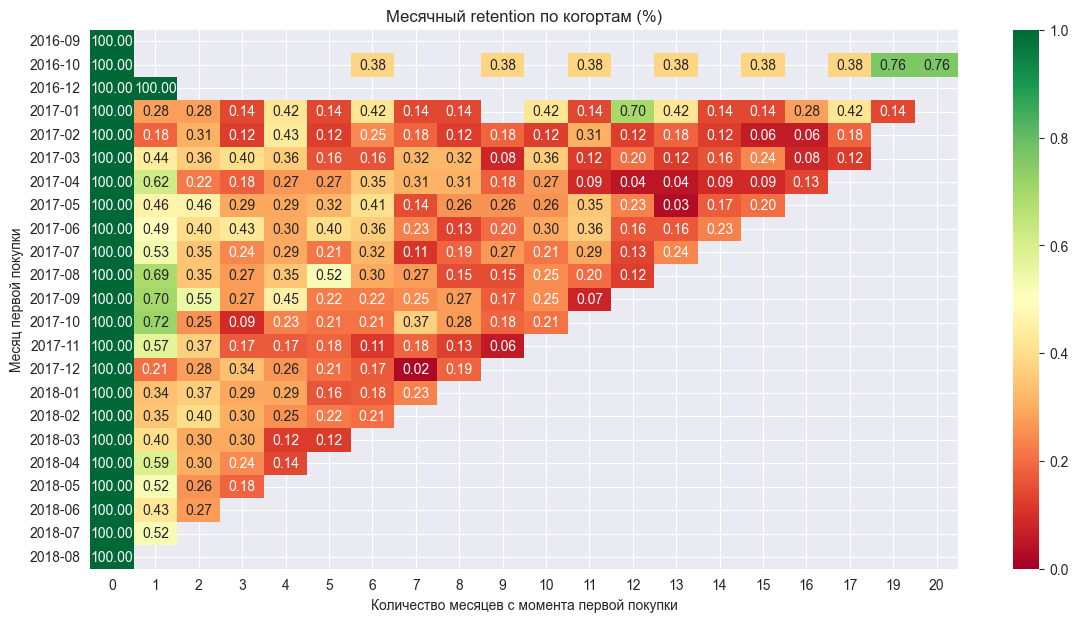

In [14]:
# В качестве пользовательского идентификатора используется customer_unique_id,
# так как customer_id является позаказным идентификатором.

# Для расчета retention учитываются только заказы со статусом delivered,
# так как они отражают завершенную покупку и реальное взаимодействие пользователя с продуктом.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')

# Смотрим на статусы заказов
print('Статусы заказов:')
print(orders['order_status'].value_counts())

# Приводим дату покупки к формату datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Объединяем таблицы заказов и клиентов
df = orders.merge(customers, on='customer_id', how='left')

# Для retention берем только доставленные заказы,
# так как они отражают завершенную покупку
df = df[df['order_status'] == 'delivered'].copy()

# В качестве пользователя используем customer_unique_id,
# так как customer_id является позаказным идентификатором
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Определяем месяц первой покупки пользователя
first_order = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

# Добавляем когорту в основной датафрейм
df = df.merge(first_order, on='customer_unique_id', how='left')

# Считаем номер месяца относительно первой покупки
df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

# Считаем число уникальных пользователей по когортам и месяцам
cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

# Определяем размер каждой когорты
cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0]
    [['cohort_month', 'customer_unique_id']]
    .rename(columns={'customer_unique_id': 'cohort_size'})
)

# Считаем retention
cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['customer_unique_id'] / cohort_data['cohort_size']

# Формируем сводную таблицу retention
retention_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention'
).sort_index()

print('Месячный retention:')
print(retention_table)

# Считаем медианный retention 1-го месяца
median_retention_month_1 = cohort_data.loc[
    cohort_data['cohort_index'] == 1, 'retention'
].median()

print('\nМедианный retention 1-го месяца:')
print(median_retention_month_1)

# Находим когорту с самым высоким retention на 3-й месяц
month_3 = cohort_data[cohort_data['cohort_index'] == 3].copy()
best_cohort_month_3 = month_3.loc[month_3['retention'].idxmax()]

print('\nКогорта с самым высоким retention на 3-й месяц:')
print('Когорта:', best_cohort_month_3['cohort_month'])
print('Retention:', best_cohort_month_3['retention'])

# Визуализация retention
retention_table_percent = retention_table * 100

plt.figure(figsize=(14, 7))

sns.heatmap(
    retention_table_percent,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1
)

plt.title('Месячный retention по когортам (%)')
plt.ylabel('Месяц первой покупки')
plt.xlabel('Количество месяцев с момента первой покупки')

plt.show()

#В ходе анализа был рассчитан месячный retention пользователей на основе когортного подхода.

#В качестве пользовательского идентификатора использовался customer_unique_id,
#так как customer_id является позаказным идентификатором.

#В расчет включались только заказы со статусом delivered, поскольку они отражают завершенную покупку
#и реальное взаимодействие пользователя с продуктом.

#Результаты показали, что:

#1. Retention резко снижается уже после первого месяца, что указывает на слабую возвращаемость пользователей.
#2. Медианный retention первого месяца составляет 0.0051 (≈0.51%), что свидетельствует о крайне низкой доле пользователей,
   #возвращающихся для повторной покупки.
#3. Даже лучшая когорта (июнь 2017) демонстрирует retention на третий месяц на уровне 0.0043 (≈0.43%),
   #что указывает на отсутствие устойчивого пользовательского поведения.

#Таким образом, продукт в текущем виде не формирует привычку повторного использования,
#и пользователи в большинстве случаев совершают разовые покупки.

#С точки зрения бизнеса это означает, что рост выручки не может быть обеспечен за счет удержания,
#и продукт в текущем виде зависит от постоянного привлечения новых пользователей.